# Phase 3 – Data Preparation

**CRISP-DM Step 3 of 5**

Goals:
- Load raw survey data and recode SPSS missing value conventions
- Filter to EU-27 SMEs
- Engineer features (RE action count, composite indices, outcome recoding)
- Produce the final model-ready dataset
- Save to `data/processed/sme_model_ready.parquet`

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_sav, save_interim, save_processed
from src.data.preprocessor import (
    recode_dk_na, recode_inap,
    filter_eu27, filter_sme,
    data_quality_report, remove_duplicates, drop_high_missing
)
from src.features.engineer import (
    RE_ACTION_COLS, RE_PLANNED_COLS, DIFFICULTY_COLS,
    compute_re_action_count, compute_re_any, compute_re_planned_count,
    compute_green_orientation,
    recode_turnover_change, recode_cost_impact, recode_employee_change,
    recode_firm_size, recode_firm_age, recode_turnover_bracket,
    recode_market_scope, recode_re_investment,
    compute_difficulty_count, add_labels,
)

sns.set_theme(style='whitegrid')
%matplotlib inline

## 3.1 Load Raw Data

In [2]:
df_raw, meta = load_sav('initial_data.sav')
print(f"Raw data: {df_raw.shape[0]:,} rows \u00d7 {df_raw.shape[1]} columns")

Loaded initial_data.sav: 18,159 rows × 236 columns
Raw data: 18,159 rows × 236 columns


## 3.2 Recode DK / NA / Inapplicable Values

SPSS convention in this survey:
- `997`, `998`, `999` = Don't know / No answer (treat as NaN)
- `999997`, `999998` = Same (for large-value variables like `dx5`)
- `9` = Inapplicable (structural missingness from skip patterns — treat as NaN)

In [3]:
# Recode standard DK/NA codes across all numeric columns
df = recode_dk_na(df_raw)

# Recode Inapplicable (9) for skip-pattern questions
INAP_COLS = [
    'q3', 'q4',
    *[f'q5.{i}' for i in range(1, 6)],
    *[f'q6.{i}' for i in range(1, 10)],
    *[f'q7.{i}' for i in range(1, 14)],
    *[f'q15.{i}' for i in range(1, 8)],
    'q10',
    *[f'q13.{i}' for i in range(1, 6)],
    *[f'dx3.{i}' for i in range(1, 8)],
    *[f'dx4.{i}' for i in range(1, 8)],
    'n1b', 'n2', 'n3',
]
INAP_COLS = [c for c in INAP_COLS if c in df.columns]
df = recode_inap(df, cols=INAP_COLS, inap_code=9.0)

print("DK/NA and Inapplicable recoding complete.")

DK/NA and Inapplicable recoding complete.


## 3.3 Filter to EU-27 SMEs

In [4]:
df = filter_eu27(df)
df = filter_sme(df)
df = remove_duplicates(df, subset=['uniqid'])
df = df.reset_index(drop=True)
print(f"Working dataset: {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns")

Filtered to EU-27: 18,159 → 14,048 rows
Filtered to SMEs (1-249 employees): 14,048 → 13,124 rows
Working dataset: 13,124 rows × 236 columns


## 3.4 Feature Engineering

### 3.4.1 Resource Efficiency Actions

In [5]:
df = compute_re_action_count(df)
df = compute_re_any(df)
df = compute_re_planned_count(df)
df = compute_difficulty_count(df)

print(f"re_action_count \u2014 mean: {df['re_action_count'].mean():.2f}, "
      f"0-action firms: {(df['re_action_count']==0).mean()*100:.1f}%")

re_action_count — mean: 4.03, 0-action firms: 7.2%


### 3.4.2 Green Orientation Composite

In [6]:
df = compute_green_orientation(df)

print(f"green_orientation \u2014 mean: {df['green_orientation'].mean():.2f}, "
      f"max: {df['green_orientation'].max()}")

green_orientation — mean: 4.99, max: 12.0


### 3.4.3 Outcome Variable Recoding

In [7]:
df = recode_turnover_change(df)
df = recode_cost_impact(df)
df = recode_employee_change(df)

print("Turnover change (recoded):")
print(df['turnover_change_3cat'].value_counts(dropna=False))

Turnover change (recoded):
turnover_change_3cat
increased    5720
unchanged    4193
decreased    2602
NaN           609
Name: count, dtype: int64


### 3.4.4 Firm-Level Controls

In [8]:
df = recode_firm_size(df)
df = recode_firm_age(df)
df = recode_turnover_bracket(df)
df = recode_market_scope(df)
df = recode_re_investment(df)

print("Firm size distribution:")
print(df['firm_size_cat'].value_counts())

Firm size distribution:
firm_size_cat
micro     5780
small     4835
medium    2509
Name: count, dtype: int64


### 3.4.5 Add Labels

In [9]:
df = add_labels(df)
print(df[['country_label', 'sector_label']].head())

  country_label   sector_label
0            AT         Retail
1            AT  Manufacturing
2            AT       Services
3            AT       Services
4            AT         Retail


## 3.5 Final Dataset Check

In [10]:
MODEL_COLS = [
    'turnover_change_ord', 'turnover_increased', 'turnover_change_3cat',
    'cost_impact_ord', 'cost_decreased',
    'emp_change_ord', 'emp_increased',
    're_action_count', 're_any_action', 're_planned_count',
    're_investment_ord', 're_invests',
    'green_orientation', 'has_green_products', 'has_climate_strategy', 'uses_renewables',
    'difficulty_count',
    'firm_size_ord', 'firm_age_ord', 'turnover_bracket_ord', 'market_scope',
    'nace_b', 'sector_label', 'country', 'country_label', 'isocntry',
    'w1_sme',
]

df_model = df[[c for c in MODEL_COLS if c in df.columns]].copy()
print(f"Model dataset: {df_model.shape[0]:,} rows \u00d7 {df_model.shape[1]} columns")
print()
missing = df_model.isna().sum()
print("Missing values in model variables:")
print(missing[missing > 0].sort_values(ascending=False))

Model dataset: 13,124 rows × 27 columns

Missing values in model variables:
cost_impact_ord         2171
cost_decreased           940
re_invests               940
re_investment_ord        940
turnover_change_3cat     609
turnover_change_ord      609
turnover_increased       609
market_scope             108
emp_change_ord            95
emp_increased             95
firm_age_ord              67
dtype: int64


In [11]:
REQUIRED = ['turnover_change_ord', 're_action_count', 'firm_size_ord', 'nace_b', 'country_label']
df_complete = df_model.dropna(subset=REQUIRED).reset_index(drop=True)

print(f"Complete cases for primary analysis: {len(df_complete):,}")
print(f"Countries represented: {df_complete['country_label'].nunique()}")
print(f"Sectors represented: {df_complete['sector_label'].nunique()}")

Complete cases for primary analysis: 12,515
Countries represented: 27
Sectors represented: 4


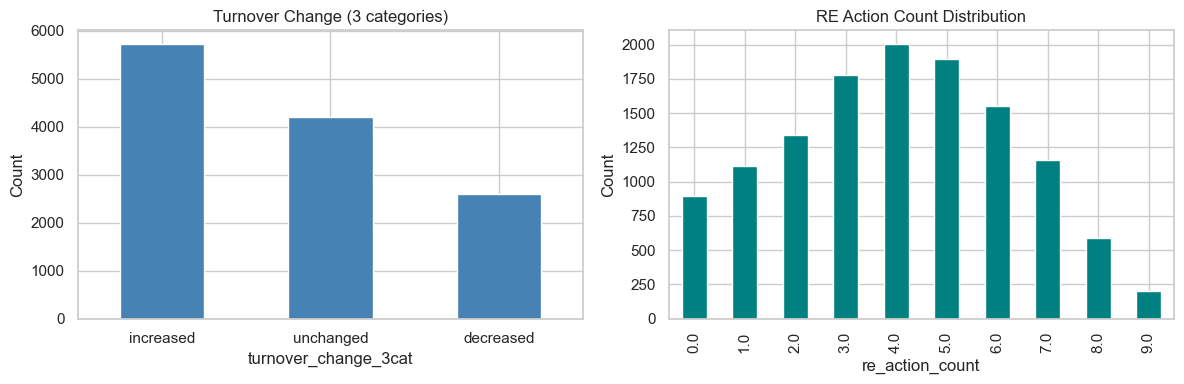

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_complete['turnover_change_3cat'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Turnover Change (3 categories)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df_complete['re_action_count'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='teal', edgecolor='white'
)
axes[1].set_title('RE Action Count Distribution')
axes[1].set_ylabel('Count')
plt.tight_layout()

## 3.6 Save Processed Datasets

In [13]:
save_interim(df_model, 'sme_eu27_engineered.parquet')
save_processed(df_complete, 'sme_model_ready.parquet')

print("\nData preparation complete.")
print(f"  Interim:   data/interim/sme_eu27_engineered.parquet  ({len(df_model):,} rows)")
print(f"  Processed: data/processed/sme_model_ready.parquet    ({len(df_complete):,} rows)")

Saved → D:\HOMEWORK (NOT PORN)\pacd\code\data\interim\sme_eu27_engineered.pkl
Saved → D:\HOMEWORK (NOT PORN)\pacd\code\data\processed\sme_model_ready.pkl

Data preparation complete.
  Interim:   data/interim/sme_eu27_engineered.parquet  (13,124 rows)
  Processed: data/processed/sme_model_ready.parquet    (12,515 rows)


## 3.7 Data Preparation Summary

| Step | Action | Output |
|------|--------|--------|
| DK/NA recoding | Replaced 997/998/999 with NaN | — |
| Inapplicable recoding | Replaced 9 (structural missing) with NaN | — |
| EU-27 filter | Kept EU member states only | — |
| SME filter | Kept scr10 \u2208 {1,2,3} (1\u2013249 employees) | — |
| Duplicate removal | Checked on `uniqid` | — |
| RE action count | Sum of q1.1\u2013q1.10 | `re_action_count` (0\u201310) |
| Green orientation | re_action_count + 3 binary indicators | `green_orientation` (0\u201313) |
| Outcome recoding | scr13a \u2192 reversed ordinal + binary + 3-cat | `turnover_change_ord` etc. |
| Firm controls | Size, age, turnover bracket, market scope | — |
| Labels | Country and sector readable names | — |
| Saved (interim) | EU-27 SME engineered dataset | `sme_eu27_engineered.parquet` |
| Saved (processed) | Complete-case model dataset | `sme_model_ready.parquet` |